## 1. Import Required Libraries

# Day 29: Data Cleaning – Deep Dive with Titanic Dataset

## Objective
In this session, we move from **EDA to action**.

By the end of this session, students will be able to:
- Identify data quality issues using EDA
- Take logical data cleaning decisions
- Handle missing values, duplicates, and outliers
- Standardize categorical variables
- Understand insights behind every data visualization
- Validate the dataset after cleaning


In [1]:
import  numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

## 2. Load the Dataset


In [2]:
df = pd.read_csv("titanic (2).csv")

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 3. Initial Dataset Health Check
Let us understand the structure and basic statistics of the dataset.


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Missing Value Analysis
We identify missing values and calculate their percentage to make informed decisions.

In [8]:
missing_count = df.isnull().sum()

missing_percent = (missing_count / len(df))* 100

pd.DataFrame({
    "Missing_count": missing_count,
    "Missing_percentage":missing_percent
}).sort_values(by = "Missing_percentage",ascending = False)

,Missing_count,Missing_percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


### Cleaning Strategy (Decision-Based)

- **Age** → Numerical column, slightly skewed → Fill with median  
- **Embarked** → Categorical column with very few missing → Fill with mode  
- **Cabin** → Very high missing percentage → Drop the column

In [9]:

df["Age"].fillna(df["Age"].median(), inplace = True)

In [10]:
df["Embarked"].fillna(df["Embarked"].mode, inplace=True)



In [11]:
df.drop(columns = ["Cabin"],inplace = True)

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5. Handling Duplicate Records
Duplicates can lead to biased analysis and incorrect model learning.


In [13]:
df.duplicated().sum()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


## 6. Cleaning Categorical Data
We standardize text data to avoid category mismatch.

In [14]:
df["Sex"] = df["Sex"].str.lower()
df["Embarked"] = df["Embarked"].str.strip()

In [15]:
df["Sex"]

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [16]:
df["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

## 7. Outlier Detection – Fare Column
We use a boxplot to visually identify outliers.

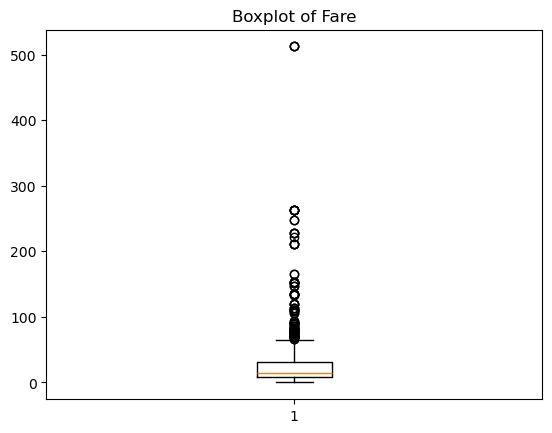

In [17]:
plt.boxplot(df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

### Insights:
- Fare is **right-skewed**, indicating some passengers paid very high prices
- Several extreme values are present beyond the upper whisker
- These outliers can significantly affect mean and variance
- Outliers may represent premium cabins and should not be blindly removed

## 8. Treating Outliers Using IQR Method (Capping)
Instead of removing outliers, we cap them to preserve data size.

In [18]:
# lower ----> iqr -----> q3 /q1------> 75 & 25th percent value 

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3- Q1

lower_whisker = Q1 - 1.5* IQR
upper_whisker = Q3 + 1.5* IQR

In [19]:
df["Fare"] = np.where(df["Fare"] > upper_whisker ,upper_whisker , df["Fare"])
df["Fare"] = np.where(df["Fare"] < lower_whisker , lower_whisker , df["Fare"])



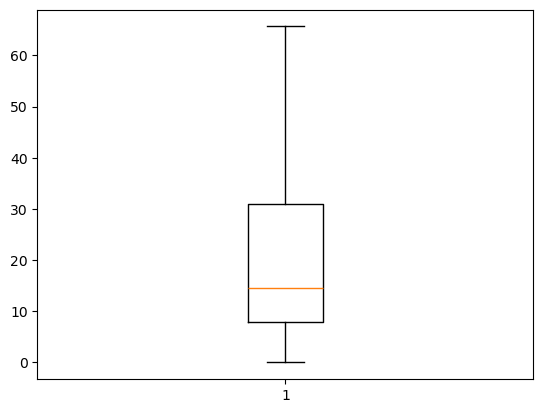

In [20]:
plt.boxplot(df["Fare"])
plt.show()

### After capping and adjusting the outliers 

## 9. Feature Engineering – Extracting Title from Name

Passenger titles like Mr, Mrs, Miss can give meaningful social and age-related information.

In [21]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


### Insights:
- Titles help identify gender and approximate age groups
- Certain titles appear rarely and may need grouping later
- Feature engineering can improve model performance significantly

## 10. Dropping Irrelevant Columns
These columns do not add predictive or analytical value.

In [22]:
# df.head()
df.drop(columns = ["PassengerId","Name","Ticket"], inplace = True)

In [23]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


## 11. Standardizing Column Names
We convert column names to lowercase for consistency.

In [24]:
df.rename(columns = lambda x :x.lower() ,inplace=True)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


## 12. Final Dataset Validation
We confirm that all cleaning steps were successful.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [26]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    2
dtype: int64

## 13. Key Takeaways
- EDA helps identify data problems
- Data cleaning requires logical decisions, not blind operations
- Outliers and missing values must be handled carefully
- Always validate data after cleaning

### Assignment
- Perform EDA again on the cleaned dataset
- Compare plots before and after cleaning
- Document at least 5 insights from the cleaned data


## FEW EXTRA ANALYSIS PROBLEM STATEMENT

## Which columns have the most missing values?

In [27]:
df.isnull().sum().sort_values(ascending=False,)
# embark have a most missing values


embarked    2
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

## How many duplicate rows exist?

In [28]:
df.duplicated().sum()

#There is no duplicate in a cleaned dataset

123

## Convert “male”, “Male”, “M” → “Male”

In [29]:
df.replace(["male","Male","M"],"Male")


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,Male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,Male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,Male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,Male,26.0,0,0,30.0000,C


## Clean spaces in string columns

In [30]:
# Remove spaces from all string columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


## Convert AGE column to numeric INT

In [31]:
df['age'] = df['age'].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    int32  
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(1), int32(1), int64(4), object(2)
memory usage: 52.3+ KB


## Find invalid or suspicious values

In [32]:
df[df.duplicated()]


,survived,pclass,sex,age,sibsp,parch,fare,embarked
47,1,3,female,28,0,0,7.7500,Q
55,1,1,male,28,0,0,35.5000,S
76,0,3,male,28,0,0,7.8958,S
77,0,3,male,28,0,0,8.0500,S
87,0,3,male,28,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
870,0,3,male,26,0,0,7.8958,S
877,0,3,male,19,0,0,7.8958,S
878,0,3,male,28,0,0,7.8958,S
884,0,3,male,25,0,0,7.0500,S


In [33]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    int32  
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(1), int32(1), int64(4), object(2)
memory usage: 52.3+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.345679,0.523008,0.381594,24.046813
std,0.486592,0.836071,13.028212,1.102743,0.806057,20.481625
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,65.634400


In [34]:
df["survived"].unique()

array([0, 1], dtype=int64)

In [35]:
df[df["survived"].isin([0,1])]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,65.6344,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27,0,0,13.0000,S
887,1,1,female,19,0,0,30.0000,S
888,0,3,female,28,1,2,23.4500,S
889,1,1,male,26,0,0,30.0000,C


In [36]:
df["pclass"].unique()

array([3, 1, 2], dtype=int64)

In [37]:
df[~df["pclass"].isin([1,2,3])]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [38]:
df["sex"].unique()
df["sex"].value_counts()


sex
male      577
female    314
Name: count, dtype: int64

In [39]:
df[df["age"] < 0]
df[df["age"] > 100]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [40]:
df[df["age"].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [41]:
df[df["sibsp"] < 0]
df[df["parch"] < 0]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [42]:
df[df["sibsp"] > 8]
df[df["parch"] > 6]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [43]:
df[df["fare"] < 0]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [44]:
df["fare"].describe()

count    891.000000
mean      24.046813
std       20.481625
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max       65.634400
Name: fare, dtype: float64

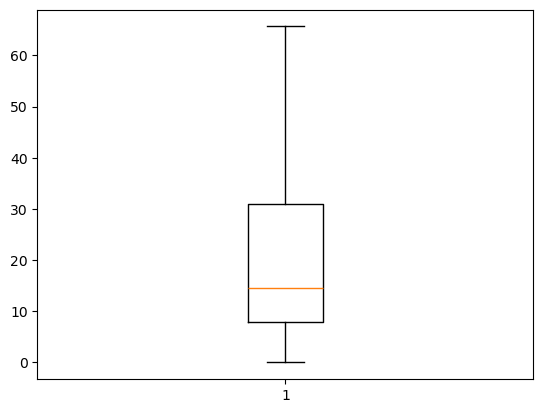

In [45]:

plt.boxplot(df["fare"].dropna())
plt.show()

In [48]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[(df["fare"] < lower) | (df["fare"] > upper)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [60]:
df.duplicated().sum()

0

In [61]:
df = df.drop_duplicates()

In [62]:
df.duplicated().sum()

0

In [63]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,65.6344,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39,0,5,29.1250,Q
887,1,1,female,19,0,0,30.0000,S
888,0,3,female,28,1,2,23.4500,S
889,1,1,male,26,0,0,30.0000,C


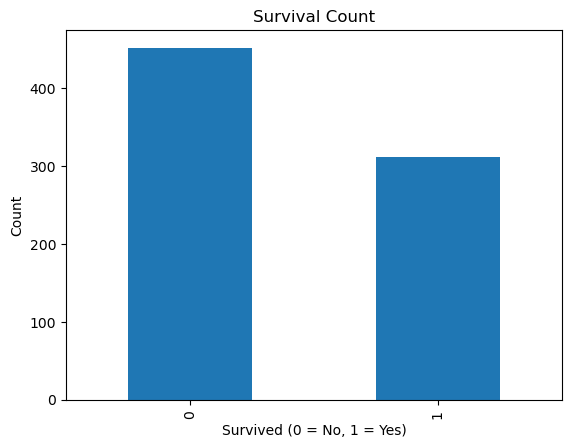

In [64]:


df["survived"].value_counts().plot(kind="bar")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Survival Count")
plt.show()

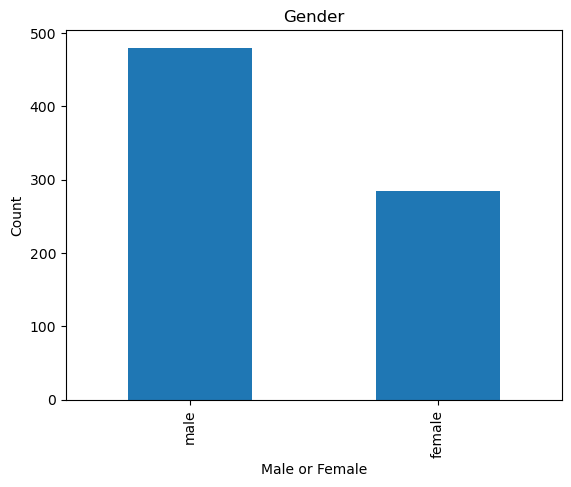

In [65]:
df["sex"].value_counts().plot(kind="bar")
plt.title("Gender")
plt.xlabel("Male or Female")
plt.ylabel("Count")
plt.show()

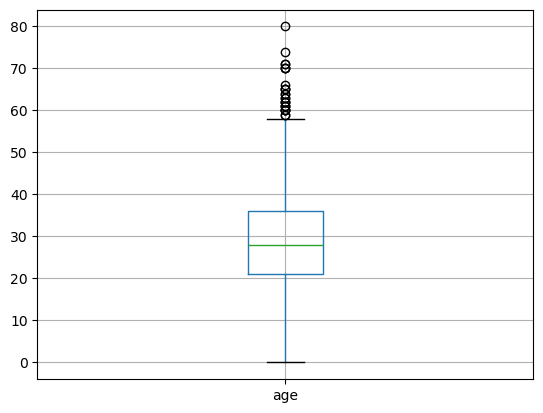

In [55]:
df.boxplot("age")
plt.show()

Text(0.5, 1.0, 'frequency of ages')

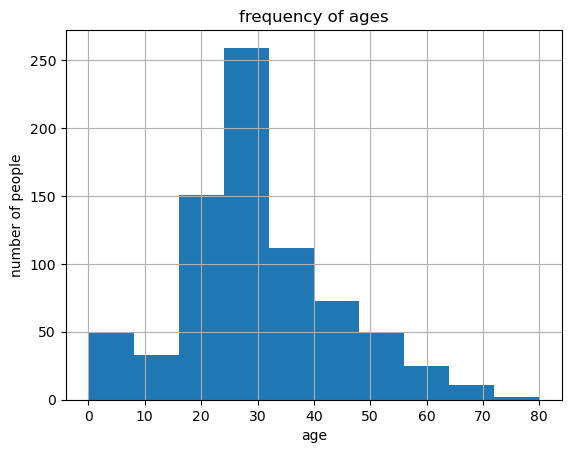

In [56]:
df.hist("age")
plt.ylabel("number of people")
plt.xlabel("age")
plt.title("frequency of ages")


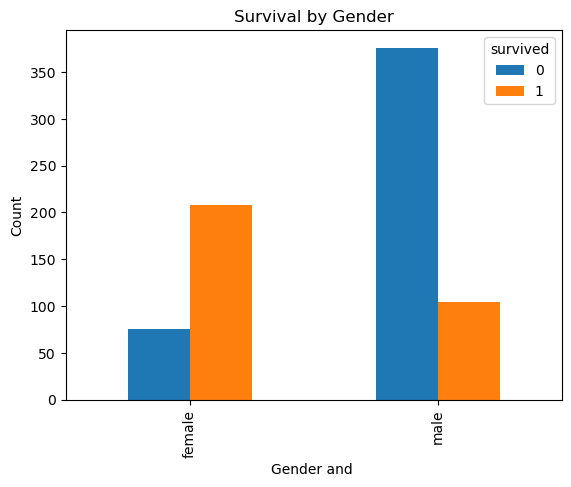

In [57]:
pd.crosstab(df["sex"], df["survived"]).plot(kind="bar")

plt.xlabel("Gender and ")
plt.ylabel("Count")
plt.title("Survival by Gender")
plt.show()